# INSTRUCTIONS:


1. What script does: trains QCNN on synthetic Gaussian dataset, saves model, then runs full validation suite
at multiple x0 centers and patch radii.
2. We can load the pre-trained QCNN model gaussian_trained_model.json file to run validation faster. (provided with the repo)
3. Bessel bound value is hard coded as K=1.51

In [2]:
pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 97.4 MB/s eta 0:00:00


In [3]:
#!/usr/bin/env python3
import time
import json
import os
import warnings
from math import comb, ceil, log
from typing import Tuple, List, Dict, Callable, Optional

import numpy as np
import pennylane as qml
from pennylane import numpy as pnp

warnings.filterwarnings("ignore")


# =============================================================================
# PART 1: DATA GENERATION
# =============================================================================

def generate_gaussian_dataset_balanced(n_samples, d_in, separation=2.0, seed=42):
    """
    Balanced binary classification in R^{d_in}.
    Label = 1 if x[0] > 0 else 0.
    Class centers at x[0] = +/- separation, other features ~ N(0,1).
    separation=2.0.
    """
    rng = np.random.default_rng(seed)
    n0 = n_samples // 2
    n1 = n_samples - n0
    X0 = rng.standard_normal((n0, d_in))
    X0[:, 0] -= separation
    X1 = rng.standard_normal((n1, d_in))
    X1[:, 0] += separation
    X = np.vstack([X0, X1])
    y = np.array([0] * n0 + [1] * n1, dtype=int)
    idx = rng.permutation(n_samples)
    return X[idx], y[idx]


def scale_for_embedding(X, clip_range=4.0):
    """
    Affine-scale features from approximately [-clip, +clip] to [0, pi].
    AngleEmbedding(rotation='Y') applies RY(x_i), and PauliZ measures cos(x_i).
    Since cos is even, mapping to [0, pi] places data on the monotone branch.
    """
    X_clipped = np.clip(X, -clip_range, clip_range)
    return (X_clipped + clip_range) / (2 * clip_range) * np.pi


def train_val_split_Xy(X, y, val_frac=0.25, seed=0):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y))
    rng.shuffle(idx)
    n_val = int(round(val_frac * len(y)))
    return X[idx[n_val:]], y[idx[n_val:]], X[idx[:n_val]], y[idx[:n_val]]


# =============================================================================
# PART 2: QCNN CIRCUIT
# =============================================================================

def create_small_qcnn_x(n_qubits=6):
    dev = qml.device("default.qubit", wires=n_qubits)
    N_PARAMS = 20
    D_IN = n_qubits

    @qml.qnode(dev, interface="autograd")
    def circuit(params, x):
        qml.AngleEmbedding(x[:n_qubits], wires=range(n_qubits), rotation="Y")
        pairs = [(0, 1), (2, 3), (4, 5)]
        for pidx, (i, j) in enumerate(pairs):
            base = pidx * 3
            qml.RY(params[base + 0], wires=i)
            qml.RY(params[base + 1], wires=j)
            qml.CNOT(wires=[i, j])
            qml.RZ(params[base + 2], wires=i)
        for pidx, (i, j) in enumerate(pairs):
            base = 9 + pidx * 2
            qml.CRZ(params[base + 0], wires=[j, i])
            qml.CRX(params[base + 1], wires=[j, i])
        active = list(range(0, n_qubits, 2))
        if len(active) >= 2:
            qml.RY(params[15], wires=active[0])
            qml.RY(params[16], wires=active[1])
            qml.CNOT(wires=[active[0], active[1]])
            qml.RZ(params[17], wires=active[0])
        qml.RY(params[18], wires=active[0])
        qml.RX(params[19], wires=active[0])
        return qml.expval(qml.PauliZ(active[0]))

    return circuit, N_PARAMS, D_IN


def cross_entropy_loss(predictions, labels, label_smoothing=0.0):
    probs = (1.0 - predictions) / 2.0
    probs = pnp.clip(probs, 1e-10, 1 - 1e-10)
    y = (1 - label_smoothing) * labels + 0.5 * label_smoothing if label_smoothing > 0 else labels
    return -pnp.mean(y * pnp.log(probs) + (1 - y) * pnp.log(1 - probs))


def compute_accuracy(preds, labels):
    return float(np.mean((preds < 0).astype(int) == labels))


# =============================================================================
# PART 3: TRAINING
# =============================================================================

def train_qcnn_with_restarts_Xy(
    circuit, n_params, X_train, y_train, X_val, y_val,
    n_epochs=200, lr=0.02, lr_decay=0.7, decay_every=50,
    patience=40, n_restarts=3, label_smoothing=0.02, seed=42,
):
    rng = np.random.default_rng(seed)
    def loss_fn_params(p, X, y):
        preds = pnp.array([circuit(p, pnp.array(x, requires_grad=False)) for x in X])
        return cross_entropy_loss(preds, y, label_smoothing=label_smoothing)
    best_overall_params = None
    best_overall_val = float("inf")
    best_log = {}
    print(f"Training with Adam + early stopping | restarts={n_restarts}")
    print("-" * 70)
    for r in range(n_restarts):
        params = pnp.array(rng.uniform(-np.pi, np.pi, n_params), requires_grad=True)
        opt = qml.AdamOptimizer(stepsize=lr)
        best_params = params.copy()
        best_val = float("inf")
        best_epoch = -1
        no_improve = 0
        t0 = time.time()
        for epoch in range(1, n_epochs + 1):
            params, tr_loss = opt.step_and_cost(lambda p: loss_fn_params(p, X_train, y_train), params)
            if decay_every > 0 and epoch % decay_every == 0:
                opt.stepsize *= lr_decay
            va_loss = float(loss_fn_params(params, X_val, y_val))
            if va_loss + 1e-12 < best_val:
                best_val = va_loss
                best_epoch = epoch
                best_params = params.copy()
                no_improve = 0
            else:
                no_improve += 1
            if epoch % 25 == 0 or epoch == 1:
                tr_preds = np.array([float(circuit(params, pnp.array(x, requires_grad=False))) for x in X_train])
                va_preds = np.array([float(circuit(params, pnp.array(x, requires_grad=False))) for x in X_val])
                print(f"[restart {r+1:02d}] epoch {epoch:3d} | "
                      f"tr {float(tr_loss):.4f} va {va_loss:.4f} | "
                      f"tr_acc {compute_accuracy(tr_preds, y_train):.1%} "
                      f"va_acc {compute_accuracy(va_preds, y_val):.1%}")
            if no_improve >= patience:
                break
        t1 = time.time() - t0
        tr_preds = np.array([float(circuit(best_params, pnp.array(x, requires_grad=False))) for x in X_train])
        va_preds = np.array([float(circuit(best_params, pnp.array(x, requires_grad=False))) for x in X_val])
        tr_acc = compute_accuracy(tr_preds, y_train)
        va_acc = compute_accuracy(va_preds, y_val)
        print(f"[restart {r+1:02d}] done | ep {best_epoch:3d} va {best_val:.4f} "
              f"tr_acc {tr_acc:.1%} va_acc {va_acc:.1%} | {t1:.0f}s")
        if best_val < best_overall_val:
            best_overall_val = best_val
            best_overall_params = np.array(best_params, dtype=float)
            best_log = {"restart": r + 1, "best_epoch": best_epoch,
                        "best_val_loss": best_val, "train_acc": tr_acc, "val_acc": va_acc}
    return best_overall_params, best_log


# =============================================================================
# PART 4: TAYLOR COEFFICIENTS + TENSOR
# =============================================================================

def compute_all_derivatives_deg2_x(loss_fn_x, x0, fd_h=0.02, verbose=True):
    D = len(x0)
    derivs = {}
    n_evals = 0
    g0 = float(loss_fn_x(x0)); n_evals += 1
    derivs[()] = g0
    if verbose:
        print(f"    g(x0) = {g0:.6f}")
    fpc = np.zeros(D); fmc = np.zeros(D)
    if verbose:
        print(f"    Computing gradient ({D} terms)...")
    for i in range(D):
        e = np.zeros(D); e[i] = 1.0
        fp = float(loss_fn_x(x0 + fd_h * e))
        fm = float(loss_fn_x(x0 - fd_h * e))
        n_evals += 2; fpc[i] = fp; fmc[i] = fm
        derivs[(i,)] = (fp - fm) / (2 * fd_h)
    if verbose:
        print(f"    Computing Hessian ({D + D*(D-1)//2} unique terms)...")
    for i in range(D):
        derivs[(i, i)] = (fpc[i] - 2 * g0 + fmc[i]) / (fd_h**2)
    for i in range(D):
        ei = np.zeros(D); ei[i] = 1.0
        for j in range(i + 1, D):
            ej = np.zeros(D); ej[j] = 1.0
            fpp = float(loss_fn_x(x0 + fd_h * ei + fd_h * ej))
            fpm = float(loss_fn_x(x0 + fd_h * ei - fd_h * ej))
            fmp = float(loss_fn_x(x0 - fd_h * ei + fd_h * ej))
            fmm = float(loss_fn_x(x0 - fd_h * ei - fd_h * ej))
            n_evals += 4
            val = (fpp - fpm - fmp + fmm) / (4 * fd_h**2)
            derivs[(i, j)] = val; derivs[(j, i)] = val
    return derivs, n_evals


def build_taylor_tensor_deg2_from_derivs(derivs, D):
    C = np.zeros((3,) * D, dtype=np.float64)
    C[tuple([0] * D)] = derivs.get((), 0.0)
    for i in range(D):
        idx = [0] * D; idx[i] = 1
        C[tuple(idx)] = derivs.get((i,), 0.0)
    for i in range(D):
        idx = [0] * D; idx[i] = 2
        C[tuple(idx)] = derivs.get((i, i), 0.0) / 2.0
        for j in range(i + 1, D):
            idx = [0] * D; idx[i] = 1; idx[j] = 1
            C[tuple(idx)] = derivs.get((i, j), 0.0)
    return C


# =============================================================================
# PART 5: TT-SVD + UTILS
# =============================================================================

def tt_svd(tensor, max_rank=None, rel_tol=1e-12):
    shape = tensor.shape; N = len(shape)
    if max_rank is None: max_rank = 10**9
    cores = []; C = tensor.copy(); r_prev = 1
    for k in range(N - 1):
        nk = shape[k]; C = C.reshape(r_prev * nk, -1)
        U, S, Vh = np.linalg.svd(C, full_matrices=False)
        s2 = S**2; total = float(np.sum(s2))
        if total <= 0: rank = 1
        else:
            tail = np.cumsum(s2[::-1])[::-1]
            thr = (rel_tol**2) * total
            r = int(np.argmax(tail <= thr)) if np.any(tail <= thr) else len(S)
            rank = max(1, r)
        rank = min(rank, max_rank, len(S))
        cores.append(U[:, :rank].reshape(r_prev, nk, rank))
        C = S[:rank, None] * Vh[:rank, :]; r_prev = rank
    cores.append(C.reshape(r_prev, shape[-1], 1))
    return cores

def tt_ranks(cores): return [1] + [c.shape[2] for c in cores]
def tt_total_size(cores): return int(sum(c.size for c in cores))
def tt_to_full(cores):
    T = cores[0]
    for k in range(1, len(cores)): T = np.tensordot(T, cores[k], axes=([-1], [0]))
    return np.squeeze(T, axis=(0, -1))


# =============================================================================
# PART 6: SURROGATE + DENSE EVAL
# =============================================================================

class TTTaylorSurrogate:
    def __init__(self, x0, tt_cores, taylor_degree):
        self.x0 = np.array(x0, dtype=float)
        self.tt_cores = tt_cores
        self.taylor_degree = int(taylor_degree)
        self.D = len(x0)
    def evaluate(self, x):
        xi = np.array(x, dtype=float) - self.x0
        p = self.taylor_degree
        feats = [np.array([xi[i] ** k for k in range(p + 1)]) for i in range(self.D)]
        res = np.einsum("ijk,j->k", self.tt_cores[0], feats[0])
        for k in range(1, len(self.tt_cores)):
            res = np.einsum("i,ijk,j->k", res, self.tt_cores[k], feats[k])
        return float(res[0])

def eval_dense_taylor_from_C(C, x, x0, p=2):
    xi = np.array(x, dtype=float) - np.array(x0, dtype=float)
    feats = [np.array([xi[i] ** k for k in range(p + 1)]) for i in range(len(xi))]
    T = C
    for f in feats: T = np.tensordot(T, f, axes=([0], [0]))
    return float(T)


# =============================================================================
# PART 7: ALS + ERM CERTIFICATION HELPERS
# =============================================================================

def _make_features_normalized(xs, x0, r, p):
    Z = (np.array(xs, dtype=float) - np.array(x0, dtype=float)[None, :]) / float(r)
    n, D = Z.shape; m = p + 1; phi_list = []
    for i in range(D):
        phi_i = np.zeros((n, m)); zi = Z[:, i]
        for k in range(m): phi_i[:, k] = zi ** k
        phi_list.append(phi_i)
    return phi_list

def _eval_tt_batch(cores, phi_list):
    n = phi_list[0].shape[0]
    v = phi_list[0] @ cores[0][0, :, :]
    for k in range(1, len(cores)):
        G = cores[k]; r_k, m, r_next = G.shape
        temp = (v @ G.reshape(r_k, m * r_next)).reshape(n, m, r_next)
        v = np.einsum("smq,sm->sq", temp, phi_list[k])
    return v[:, 0].copy()

def _contract_left_step(Lk, Gk, phik):
    n, r_k = Lk.shape; _, m, r_next = Gk.shape
    tmp = (Lk @ Gk.reshape(r_k, m * r_next)).reshape(n, m, r_next)
    return np.einsum("smq,sm->sq", tmp, phik)

def _contract_right_step(Gk, Rkp1, phik):
    tmp = np.einsum("ajb,sb->saj", Gk, Rkp1)
    return np.einsum("saj,sj->sa", tmp, phik)

def _build_left_cache(cores, phi_list):
    D = len(cores); n = phi_list[0].shape[0]
    left = [None] * (D + 1); left[0] = np.ones((n, 1))
    for k in range(D): left[k + 1] = _contract_left_step(left[k], cores[k], phi_list[k])
    return left

def _build_right_cache(cores, phi_list):
    D = len(cores); n = phi_list[0].shape[0]
    right = [None] * (D + 1); right[D] = np.ones((n, 1))
    for k in range(D - 1, -1, -1): right[k] = _contract_right_step(cores[k], right[k + 1], phi_list[k])
    return right

def _solve_ridge(A, y, lam):
    if lam <= 0: return np.linalg.lstsq(A, y, rcond=None)[0]
    sqrt_lam = np.sqrt(lam)
    A_aug = np.vstack([A, sqrt_lam * np.eye(A.shape[1])])
    y_aug = np.concatenate([y, np.zeros(A.shape[1])])
    return np.linalg.lstsq(A_aug, y_aug, rcond=None)[0]

def _pad_or_truncate_core(core_src, target_shape, rng):
    r_in_s, m_s, r_out_s = core_src.shape
    r_in_t, m_t, r_out_t = target_shape
    result = rng.normal(0, 1e-6, target_shape)
    r_in = min(r_in_s, r_in_t); r_out = min(r_out_s, r_out_t)
    result[:r_in, :, :r_out] = core_src[:r_in, :, :r_out]
    return result

def als_tt_fit(phi_list, y, chi, n_sweeps=15, lam_reg=1e-4, seed=42,
               n_restarts=3, init_cores=None, verbose=False, return_init_mse=False):
    rng = np.random.default_rng(seed)
    y = np.array(y, dtype=float); n = y.shape[0]; D = len(phi_list); m = phi_list[0].shape[1]
    ranks = [1]
    for k in range(1, D): ranks.append(min(chi, m**k, m ** (D - k)))
    ranks.append(1)
    best_cores = None; best_mse = float("inf"); best_init_mse = None
    for rr in range(n_restarts):
        if rr == 0 and init_cores is not None:
            cores = [_pad_or_truncate_core(init_cores[k], (ranks[k], m, ranks[k + 1]), rng) for k in range(D)]
        else:
            y_mean = float(np.mean(y)); base = (abs(y_mean) + 1e-12) ** (1.0 / D)
            sign = 1.0 if y_mean >= 0 else -1.0; cores = []
            for k in range(D):
                G = np.zeros((ranks[k], m, ranks[k + 1]))
                G[0, 0, 0] = (sign * base) if k == 0 else base
                G += rng.normal(0, 1e-4, G.shape); cores.append(G)
        init_preds = _eval_tt_batch(cores, phi_list)
        init_mse = float(np.mean((init_preds - y) ** 2))
        for sweep in range(n_sweeps):
            right = _build_right_cache(cores, phi_list); left_k = np.ones((n, 1))
            for k in range(D):
                Rkp1 = right[k + 1]; r_k = left_k.shape[1]; r_next = Rkp1.shape[1]
                A = (left_k[:, :, None, None] * phi_list[k][:, None, :, None] * Rkp1[:, None, None, :]).reshape(n, r_k * m * r_next)
                g = _solve_ridge(A, y, lam_reg); cores[k] = g.reshape(r_k, m, r_next)
                left_k = _contract_left_step(left_k, cores[k], phi_list[k])
            left = _build_left_cache(cores, phi_list); right_kp1 = np.ones((n, 1))
            for k in range(D - 1, -1, -1):
                Lk = left[k]; r_k = Lk.shape[1]; r_next = right_kp1.shape[1]
                A = (Lk[:, :, None, None] * phi_list[k][:, None, :, None] * right_kp1[:, None, None, :]).reshape(n, r_k * m * r_next)
                g = _solve_ridge(A, y, lam_reg); cores[k] = g.reshape(r_k, m, r_next)
                right_kp1 = _contract_right_step(cores[k], right_kp1, phi_list[k])
            if verbose and (sweep == 0 or (sweep + 1) % 5 == 0):
                preds = _eval_tt_batch(cores, phi_list); mse = float(np.mean((preds - y) ** 2))
                print(f"    [ALS restart {rr+1}/{n_restarts}] sweep {sweep+1:02d}/{n_sweeps} | train MSE {mse:.3e}")
        preds = _eval_tt_batch(cores, phi_list); mse = float(np.mean((preds - y) ** 2))
        if mse < best_mse:
            best_mse = mse; best_cores = [c.copy() for c in cores]; best_init_mse = init_mse
    return best_cores, best_mse, (best_init_mse if return_init_mse else None)

def build_C_normalized(C, r):
    Cn = np.zeros_like(C); it = np.nditer(C, flags=["multi_index"])
    while not it.finished:
        midx = it.multi_index; Cn[midx] = C[midx] * (r ** sum(midx)); it.iternext()
    return Cn

def sample_ball_uniform_volume(x0, r, n, rng):
    x0 = np.array(x0, dtype=float); D = x0.size
    d = rng.standard_normal((n, D)); d = d / np.linalg.norm(d, axis=1, keepdims=True)
    radii = r * (rng.uniform(0, 1, n) ** (1.0 / D))
    return x0[None, :] + d * radii[:, None]

def unit_test_als_fits_certificate(C, x0, p, r, chi, n_train, seed=2026, als_sweeps=20, als_restarts=2, als_lam=1e-10):
    rng = np.random.default_rng(seed); C_norm = build_C_normalized(C, r)
    cert_cores = tt_svd(C_norm, max_rank=chi, rel_tol=0.0)
    xs = sample_ball_uniform_volume(x0, r, n_train, rng)
    phi = _make_features_normalized(xs, x0, r, p)
    y = _eval_tt_batch(cert_cores, phi)
    print("=" * 80)
    print("UNIT TEST: ALS should fit certificate predictions nearly exactly (DATA SPACE)")
    print("=" * 80)
    print(f"chi={chi} | n_train={n_train} | sweeps={als_sweeps} | lam={als_lam:g}")
    cores_fit, mse_fit, init_mse = als_tt_fit(phi, y, chi=chi, n_sweeps=als_sweeps, lam_reg=als_lam,
        seed=seed + 7, n_restarts=als_restarts, init_cores=cert_cores, verbose=True, return_init_mse=True)
    y_hat = _eval_tt_batch(cores_fit, phi)
    mse_final = float(np.mean((y_hat - y) ** 2)); max_err = float(np.max(np.abs(y_hat - y)))
    print(f"Init MSE:   {init_mse:.3e}"); print(f"Final MSE:  {mse_final:.3e}")
    print(f"Max error:  {max_err:.3e}"); print(f"PASS: Final MSE should be << 1e-8"); print()

def erm_certification_angle(C, x0, g_fn, p, r, chi_list, K_bessel,
    n_train, n_test, als_sweeps=20, als_restarts=3, als_lam_base=1e-5, seed=555, verbose_als=False):
    rng = np.random.default_rng(seed); x0 = np.array(x0, dtype=float); D = x0.size
    K_pow = float(K_bessel ** D); C_norm = build_C_normalized(C, r)
    xs_train = sample_ball_uniform_volume(x0, r, n_train, rng)
    xs_test = sample_ball_uniform_volume(x0, r, n_test, rng)
    print(f"  Sampling {n_train} train + {n_test} test points in data ball...")
    t0 = time.time()
    y_train = np.array([g_fn(x) for x in xs_train], dtype=float)
    y_test = np.array([g_fn(x) for x in xs_test], dtype=float)
    print(f"  Done ({time.time() - t0:.1f}s)"); print()
    phi_train = _make_features_normalized(xs_train, x0, r, p)
    phi_test = _make_features_normalized(xs_test, x0, r, p)
    taylor_test = np.array([eval_dense_taylor_from_C(C, x, x0, p) for x in xs_test])
    trunc_abs = np.abs(y_test - taylor_test); trunc_max = float(np.max(trunc_abs))
    trunc_rmse = float(np.sqrt(np.mean(trunc_abs ** 2)))
    print("=" * 120)
    print("ERM CERTIFICATION (DATA SPACE, STABILIZED ALS): ERM vs CERTIFICATE + DETERMINISTIC BOUND")
    print("=" * 120)
    print(f"Radius r={r:.3f} | p={p} | D={D} | K={K_bessel:.4f} | K^D={K_pow:.2f}")
    print(f"ALS: sweeps={als_sweeps} | restarts={als_restarts} | lam_base={als_lam_base:g} (scaled by chi)")
    print(f"Warm-start: first restart initialized from certificate cores")
    print(f"Truncation proxy: trunc_max={trunc_max:.3e} | trunc_rmse={trunc_rmse:.3e}"); print()
    hdr = (f"{'chi':>4} {'lam':>9} | {'||C-Cchi||':>10} {'K^D*||.||':>10} {'E_det':>10} | "
           f"{'cert_trMSE':>10} {'erm_trMSE':>10} {'tr_ratio':>8} | "
           f"{'cert_RMSE':>9} {'erm_RMSE':>9} {'te_ratio':>8} | "
           f"{'cert_max':>9} {'erm_max':>9} | {'cert<=E':>7} | {'t(s)':>5}")
    print(hdr); print("-" * len(hdr))
    for chi in chi_list:
        lam_chi = als_lam_base * chi
        cert_cores = tt_svd(C_norm, max_rank=chi, rel_tol=0.0)
        C_chi_full = tt_to_full(cert_cores); approx_F = float(np.linalg.norm(C_norm - C_chi_full))
        E_det = trunc_max + K_pow * approx_F
        cert_tr = _eval_tt_batch(cert_cores, phi_train); cert_te = _eval_tt_batch(cert_cores, phi_test)
        cert_tr_mse = float(np.mean((y_train - cert_tr) ** 2))
        cert_rmse = float(np.sqrt(np.mean((y_test - cert_te) ** 2)))
        cert_max = float(np.max(np.abs(y_test - cert_te)))
        t0 = time.time()
        erm_cores, erm_mse, _ = als_tt_fit(phi_train, y_train, chi=chi, n_sweeps=als_sweeps,
            lam_reg=lam_chi, seed=seed + 17 * chi, n_restarts=als_restarts,
            init_cores=cert_cores, verbose=verbose_als, return_init_mse=False)
        t_als = time.time() - t0
        erm_tr = _eval_tt_batch(erm_cores, phi_train); erm_te = _eval_tt_batch(erm_cores, phi_test)
        erm_tr_mse = float(np.mean((y_train - erm_tr) ** 2))
        erm_rmse = float(np.sqrt(np.mean((y_test - erm_te) ** 2)))
        erm_max = float(np.max(np.abs(y_test - erm_te)))
        c_ok = "Y" if cert_max <= 1.05 * E_det else "N"
        ratio_tr = erm_tr_mse / cert_tr_mse if cert_tr_mse > 0 else float("inf")
        ratio_te = erm_rmse / cert_rmse if cert_rmse > 0 else float("inf")
        print(f"{chi:>4d} {lam_chi:>9.1e} | {approx_F:>10.3e} {K_pow*approx_F:>10.3e} {E_det:>10.3e} | "
              f"{cert_tr_mse:>10.3e} {erm_tr_mse:>10.3e} {ratio_tr:>8.2f} | "
              f"{cert_rmse:>9.3e} {erm_rmse:>9.3e} {ratio_te:>8.2f} | "
              f"{cert_max:>9.3e} {erm_max:>9.3e} | {c_ok:>7} | {t_als:>5.1f}")
    print("-" * len(hdr)); print()


# =============================================================================
# PART 8: PER-x0 VALIDATION SUITE
# =============================================================================

def run_single_x0(g_fn, x0, D_IN, x0_idx, x0_label,
                  fd_h=0.02,
                  chi_sweep=[1, 2, 3, 4, 5, 6, 7, 8, 10],
                  remark_radius=0.10, remark_n_probe=60,
                  radii=[0.05, 0.10, 0.20, 0.40, 0.60, 0.80, 1.00],
                  chi_list=[1, 2, 3, 4, 5],
                  n_probe=100, seed_base=42,
                  full_tables=False):
    """
    Run full validation suite at one x0.
    """

    print()
    print("#" * 110)
    print(f"#  x0[{x0_idx}]: {x0_label}")
    print(f"#  x0 = [{', '.join(f'{v:.4f}' for v in x0)}]")
    print(f"#  g(x0) = {g_fn(x0):.6f}")
    print("#" * 110)
    print()

    # --- Taylor coefficients (fixed FD_H) ---
    t0 = time.time()
    derivs, n_evals = compute_all_derivatives_deg2_x(g_fn, x0, fd_h=fd_h, verbose=True)
    C = build_taylor_tensor_deg2_from_derivs(derivs, D_IN)
    t_taylor = time.time() - t0

    C_norm_val = float(np.linalg.norm(C))
    nnz = int(np.count_nonzero(C))
    tt_full = tt_svd(C, max_rank=50, rel_tol=0.0)
    ranks_full = tt_ranks(tt_full)
    tt_size_full = tt_total_size(tt_full)

    print(f"    {n_evals} circuit evals | {t_taylor:.2f}s")
    print(f"    Tensor: {C.shape} | ||C||_F={C_norm_val:.6e} | NNZ={nnz}")
    print(f"    TT-SVD ranks (no truncation): {ranks_full}")
    print()

    # --- Remark 5.1 ---
    rng_remark = np.random.default_rng(seed_base + x0_idx * 100 + 777)
    disp = rng_remark.standard_normal((remark_n_probe, D_IN))
    disp = disp / np.linalg.norm(disp, axis=1, keepdims=True) * remark_radius
    xs_remark = x0[None, :] + disp
    exact_remark = np.array([g_fn(x) for x in xs_remark])
    taylor_remark = np.array([eval_dense_taylor_from_C(C, x, x0, 2) for x in xs_remark])
    trunc_rmse = float(np.sqrt(np.mean((exact_remark - taylor_remark) ** 2)))

    print(f"  Remark 5.1 (r={remark_radius}): Truncation RMSE = {trunc_rmse:.3e}")
    print(f"  {'chi':>5} {'||C-Cchi||/||C||':>18} {'TT_RMSE':>12} {'TOTAL_RMSE':>12} {'TT/TRUNC':>10}")
    print(f"  {'-'*65}")

    chi_threshold = None
    for chi in chi_sweep:
        cores_chi = tt_svd(C, max_rank=chi, rel_tol=0.0)
        C_chi = tt_to_full(cores_chi)
        tt_rel = float(np.linalg.norm(C - C_chi) / (C_norm_val + 1e-30))
        surr = TTTaylorSurrogate(x0, cores_chi, 2)
        tt_vals = np.array([surr.evaluate(x) for x in xs_remark])
        tt_rmse = float(np.sqrt(np.mean((taylor_remark - tt_vals) ** 2)))
        total_rmse = float(np.sqrt(np.mean((exact_remark - tt_vals) ** 2)))
        ratio = tt_rmse / trunc_rmse if trunc_rmse > 0 else float("inf")
        print(f"  {chi:>5d} {tt_rel:>18.3e} {tt_rmse:>12.3e} {total_rmse:>12.3e} {ratio:>10.3f}")
        if chi_threshold is None and ratio < 0.01:
            chi_threshold = chi

    print(f"  → χ threshold (TT/TRUNC < 0.01): χ≥{chi_threshold}")

    # --- Patch size sweep (fixed C, rel_tol=0.0) ---
    rng_sweep = np.random.default_rng(seed_base + x0_idx * 100)

    # Pre-compute TT at each chi
    tt_by_chi = {}; C_approx_by_chi = {}
    for chi in chi_list:
        cores = tt_svd(C, max_rank=chi, rel_tol=0.0)
        tt_by_chi[chi] = cores
        C_approx_by_chi[chi] = tt_to_full(cores)

    all_results = []
    for radius in radii:
        directions = rng_sweep.standard_normal((n_probe, D_IN))
        directions = directions / np.linalg.norm(directions, axis=1, keepdims=True)
        u = rng_sweep.uniform(0, 1, n_probe) ** (1.0 / D_IN)
        probe_pts = x0[None, :] + directions * (radius * u)[:, np.newaxis]

        exact_vals = np.array([g_fn(x) for x in probe_pts])
        dense_vals = np.array([eval_dense_taylor_from_C(C, x, x0, 2) for x in probe_pts])
        taylor_rmse = float(np.sqrt(np.mean((exact_vals - dense_vals) ** 2)))
        taylor_max = float(np.max(np.abs(exact_vals - dense_vals)))

        for chi in chi_list:
            surr = TTTaylorSurrogate(x0, tt_by_chi[chi], 2)
            surr_vals = np.array([surr.evaluate(x) for x in probe_pts])
            total_rmse = float(np.sqrt(np.mean((exact_vals - surr_vals) ** 2)))
            total_max = float(np.max(np.abs(exact_vals - surr_vals)))
            tt_only_rmse = float(np.sqrt(np.mean((dense_vals - surr_vals) ** 2)))
            tt_tensor_rel = float(np.linalg.norm(C - C_approx_by_chi[chi]) / (C_norm_val + 1e-30))
            rel_err = total_rmse / (np.mean(np.abs(exact_vals)) + 1e-30)

            all_results.append({
                'radius': radius, 'chi': chi,
                'taylor_rmse': taylor_rmse, 'taylor_max': taylor_max,
                'tt_tensor_rel': tt_tensor_rel, 'tt_only_rmse': tt_only_rmse,
                'total_rmse': total_rmse, 'total_max': total_max,
                'rel_err': rel_err,
            })

    # --- Print tables ---
    g_x0 = abs(g_fn(x0))

    if full_tables:
        _print_full_tables(all_results, radii, chi_list, tt_by_chi, C_approx_by_chi,
                           C, C_norm_val, ranks_full, fd_h, g_x0, D_IN)
    else:
        # Compact table (best chi only)
        best_chi = max(chi_list)
        print(f"\n  Patch Sweep (χ={best_chi}, TT lossless):")
        print(f"  {'r':>6} | {'Taylor RMSE':>12} | {'Total RMSE':>12} | {'Rel Err':>8}")
        print(f"  {'─'*50}")
        for radius in radii:
            e = next(r for r in all_results if r['radius'] == radius and r['chi'] == best_chi)
            print(f"  {radius:>6.2f} | {e['taylor_rmse']:>12.3e} | {e['total_rmse']:>12.3e} | {e['rel_err']:>7.2%}")

    # --- Speedup ---
    n_speed = 50
    rng_speed = np.random.default_rng(seed_base + x0_idx * 100 + 999)
    xs_speed = x0[None, :] + rng_speed.standard_normal((n_speed, D_IN)) * 0.05
    surr_full = TTTaylorSurrogate(x0, tt_by_chi[max(chi_list)], 2)
    t0 = time.time()
    for x in xs_speed: _ = g_fn(x)
    t_exact = time.time() - t0
    t0 = time.time()
    for x in xs_speed: _ = surr_full.evaluate(x)
    t_surr = time.time() - t0
    speedup = t_exact / t_surr if t_surr > 0 else float("inf")
    print(f"\n  Speedup: {speedup:.0f}x ({t_exact/n_speed*1000:.2f} ms/eval → {t_surr/n_speed*1000:.3f} ms/eval)")

    # Build sweep_results in compact form for aggregate table
    best_chi = max(chi_list)
    sweep_compact = []
    for radius in radii:
        e = next(r for r in all_results if r['radius'] == radius and r['chi'] == best_chi)
        sweep_compact.append({
            'radius': radius, 'taylor_rmse': e['taylor_rmse'],
            'total_rmse': e['total_rmse'], 'rel_err': e['rel_err'],
        })

    return {
        'x0_idx': x0_idx, 'x0_label': x0_label,
        'g_x0': g_fn(x0), 'ranks_full': ranks_full,
        'nnz': nnz, 'C_norm': C_norm_val,
        'chi_threshold': chi_threshold,
        'trunc_rmse_r01': trunc_rmse,
        'sweep_results': sweep_compact,
        'all_results': all_results,
        'speedup': speedup,
        'C': C, 'tt_by_chi': tt_by_chi,
    }


def _print_full_tables(all_results, radii, chi_list, tt_by_chi, C_approx_by_chi,
                        C, C_norm_val, ranks_full, fd_h, g_x0, D_IN):
    """Print Tables A-E (full format, for primary x0)."""

    print()
    print("=" * 110)
    print("TABLE A: Total Surrogate RMSE  [radius × chi]")
    print("=" * 110)
    header = f"{'r':>6} | {'Taylor':>11}"
    for chi in chi_list: header += f" | {'χ='+str(chi):>11}"
    print(header); print("─" * len(header))
    for radius in radii:
        rr = [r for r in all_results if r['radius'] == radius]
        line = f"{radius:>6.2f} | {rr[0]['taylor_rmse']:>11.3e}"
        for chi in chi_list:
            e = next(r for r in rr if r['chi'] == chi)
            line += f" | {e['total_rmse']:>11.3e}"
        print(line)
    print()

    print("=" * 110)
    print("TABLE B: TT Tensor Error  ||C - C_χ|| / ||C||  [radius × chi]")
    print("  (Radius-independent: same C decomposed once)")
    print("=" * 110)
    header = f"{'r':>6}"
    for chi in chi_list: header += f" | {'χ='+str(chi):>13}"
    print(header); print("─" * len(header))
    for radius in radii:
        rr = [r for r in all_results if r['radius'] == radius]
        line = f"{radius:>6.2f}"
        for chi in chi_list:
            e = next(r for r in rr if r['chi'] == chi)
            line += f" | {e['tt_tensor_rel']:>13.3e}"
        print(line)
    print()

    print("=" * 110)
    print("TABLE C: Relative Error (RMSE / |g(x0)|)  [radius × chi]")
    print("=" * 110)
    header = f"{'r':>6} | {'Taylor':>11}"
    for chi in chi_list: header += f" | {'χ='+str(chi):>11}"
    print(header); print("─" * len(header))
    for radius in radii:
        rr = [r for r in all_results if r['radius'] == radius]
        line = f"{radius:>6.2f} | {rr[0]['taylor_rmse']/(g_x0+1e-30):>10.2%}"
        for chi in chi_list:
            e = next(r for r in rr if r['chi'] == chi)
            line += f" | {e['rel_err']:>10.2%}"
        print(line)
    print()

    print("=" * 110)
    print("TABLE D: TT Decomposition Summary (single C, computed once)")
    print("=" * 110)
    print(f"  FD_H = {fd_h} (fixed)")
    print(f"  TT-SVD ranks (no truncation): {ranks_full}")
    print(f"  ||C||_F = {C_norm_val:.6e}")
    print()
    print(f"  {'χ':>4} | {'Ranks':>28} | {'NNZ':>6} | {'||C-Cχ||/||C||':>15} | {'Compression':>12}")
    print(f"  {'─'*75}")
    for chi in chi_list:
        cores = tt_by_chi[chi]
        r = tt_ranks(cores); sz = tt_total_size(cores)
        err = float(np.linalg.norm(C - C_approx_by_chi[chi]) / (C_norm_val + 1e-30))
        print(f"  {chi:>4} | {str(r):>28} | {sz:>6} | {err:>15.3e} | {C.size/sz:>11.1f}x")
    print()


    # TABLE E
    D = D_IN
    tolerances = [1e-2, 1e-3, 1e-4, 1e-5]
    best_chi = max(chi_list)
    print("=" * 110)
    print("TABLE E: Resource Scaling — Required degree p to meet tolerance at each radius")
    print("         (Analytical extrapolation from empirical p=2 results)")
    print("=" * 110)
    print()
    header = f"{'r':>6} | {'p=2 RMSE':>10} | {'p=2 Rel%':>8}"
    for tol in tolerances: header += f" | {'ε='+f'{tol:.0e}':>8}"
    print(header); print("─" * len(header))
    for radius in radii:
        rr = [r for r in all_results if r['radius'] == radius]
        e = next(r for r in rr if r['chi'] == best_chi)
        taylor_err = e['taylor_rmse']; rel_err_pct = e['rel_err'] * 100
        line = f"{radius:>6.2f} | {taylor_err:>10.3e} | {rel_err_pct:>7.2f}%"
        for tol in tolerances:
            if taylor_err <= tol: req_p = 2
            elif radius >= 1.0: req_p = None
            else:
                ratio = tol / taylor_err
                if ratio >= 1: req_p = 2
                else:
                    p_extra = log(ratio) / log(radius)
                    req_p = max(2, ceil(2 + p_extra))
            line += f" | {'p='+str(req_p) if req_p is not None else '—':>8}"
        print(line)
    print()
    print("  Reference: Construction cost (circuit evaluations) per degree p, D=6")
    print("  " + "─" * 70)
    print(f"  {'p':>4} | {'Unique derivs':>15} | {'FD evals (est.)':>17} | {'d_eff (χ=3)':>14} | {'Cost vs p=2':>12}")
    print("  " + "─" * 70)
    for p in [1, 2, 3, 4, 5, 6]:
        n_derivs = comb(D + p, p)
        if p == 1: fd_evals = 1 + 2 * D
        elif p == 2: fd_evals = 73
        else:
            fd_evals = 1
            for k in range(1, p + 1):
                n_k = comb(D + k - 1, k)
                fd_evals += n_k * (2 ** k)
        d_eff = D * (p + 1) * (3 ** 2)
        ratio = fd_evals / 73
        print(f"  {p:>4} | {n_derivs:>15} | {fd_evals:>17} | {d_eff:>14} | {ratio:>11.1f}x")
    print()


# =============================================================================
# PART 9: MAIN
# =============================================================================

def main():
    print("=" * 110)
    print("TT-PAC DEMO — SYNTHETIC GAUSSIAN (INTEGRATED: TRAINING + MULTI-x0 SWEEP)")
    print("=" * 110)
    print()

    # --- Config ---
    N_QUBITS = 6; D_IN = N_QUBITS
    MODEL_SAVE_PATH = "gaussian_trained_model.json"
    SKIP_TRAINING = os.path.exists(MODEL_SAVE_PATH)
    N_TRAIN_TOTAL = 300; N_TEST = 150; VAL_FRAC = 0.25
    N_EPOCHS = 200; LR = 0.02; LR_DECAY = 0.7; DECAY_EVERY = 50
    PATIENCE = 40; N_RESTARTS = 3; LABEL_SMOOTH = 0.02
    FD_H = 0.02
    TAYLOR_DEGREE = 2; TT_MAX_RANK = 10
    CHI_SWEEP = [1, 2, 3, 4, 5, 6, 7, 8, 10]
    REMARK_RADIUS = 0.10; REMARK_N_PROBE = 60
    CERT_RADIUS = 0.10; CERT_CHI_LIST = [1, 2, 3, 4, 5]
    K_BESSEL = 1.51; CERT_N_TRAIN = 600; CERT_N_TEST = 200
    ALS_SWEEPS = 20; ALS_RESTARTS = 4; ALS_LAM_BASE = 1e-7; ALS_VERBOSE = False
    RUN_UNIT_TEST = True; UT_CHI = 5; UT_N = 250

    print("Configuration:")
    print(f"  Dataset: Synthetic Gaussian (balanced binary, D={D_IN}, separation=2.0)")
    print(f"  Qubits: {N_QUBITS} | Input dim D={D_IN}")
    print(f"  Params: N=20 (independent weights per qubit pair)")
    print(f"  Data: train_total={N_TRAIN_TOTAL}, test={N_TEST}, val_frac={VAL_FRAC}")
    print(f"  Embedding: scale_for_embedding (clip=4, map to [0, pi])")
    print(f"  Train: epochs={N_EPOCHS}, restarts={N_RESTARTS}")
    print(f"  Taylor: p={TAYLOR_DEGREE} | FD_H={FD_H}")
    print(f"  Certificate/ERM: r={CERT_RADIUS}, chi_list={CERT_CHI_LIST}")
    print(f"  ALS: sweeps={ALS_SWEEPS}, restarts={ALS_RESTARTS}, lam_base={ALS_LAM_BASE:g} (x chi)")
    print(f"  ERM samples: train={CERT_N_TRAIN}, test={CERT_N_TEST}")
    print()

    # ================================================================
    # STEP 1: DATA
    # ================================================================
    print("=" * 70)
    print("STEP 1: GENERATING BALANCED GAUSSIAN DATASET")
    print("=" * 70); print()
    X_all, y_all = generate_gaussian_dataset_balanced(N_TRAIN_TOTAL, D_IN, separation=2.0, seed=42)
    X_test, y_test = generate_gaussian_dataset_balanced(N_TEST, D_IN, separation=2.0, seed=123)
    X_all = scale_for_embedding(X_all)
    X_test = scale_for_embedding(X_test)
    X_train, y_train, X_val, y_val = train_val_split_Xy(X_all, y_all, val_frac=VAL_FRAC, seed=999)
    print(f"  Train: {len(y_train)} | Val: {len(y_val)} | Test: {len(y_test)}")
    print()

    # ================================================================
    # STEP 2: TRAINING / MODEL LOADING
    # ================================================================
    print("=" * 70)
    print("STEP 2: TRAINING QCNN-LIKE CIRCUIT ON GAUSSIAN DATA")
    print("=" * 70); print()
    circuit, n_params, d_in_model = create_small_qcnn_x(N_QUBITS)
    print(f"Model: N={n_params} params | Input dim D={D_IN} | AngleEmbedding(Y)")

    if SKIP_TRAINING:
        print(f"  >>> Found saved model at {MODEL_SAVE_PATH} — skipping training!")
        with open(MODEL_SAVE_PATH, 'r') as f:
            saved = json.load(f)
        theta_star = np.array(saved['theta_star'], dtype=float)
        train_acc = saved['train_acc']
        val_acc = saved['val_acc']
        test_acc = saved['test_acc']
        print(f"  Loaded: {len(theta_star)} params")
        print(f"  Train: {train_acc:.1%} | Val: {val_acc:.1%} | Test: {test_acc:.1%}")
        print()
    else:
        print(f"Training on {len(y_train)} samples (from {N_TRAIN_TOTAL} total)"); print()
        t0 = time.time()
        optimal_params, train_log = train_qcnn_with_restarts_Xy(
            circuit, n_params, X_train, y_train, X_val, y_val,
            n_epochs=N_EPOCHS, lr=LR, lr_decay=LR_DECAY, decay_every=DECAY_EVERY,
            patience=PATIENCE, n_restarts=N_RESTARTS, label_smoothing=LABEL_SMOOTH, seed=42)
        t_train = time.time() - t0
        test_preds = np.array([float(circuit(pnp.array(optimal_params, requires_grad=False),
                                             pnp.array(x, requires_grad=False))) for x in X_test])
        train_preds = np.array([float(circuit(pnp.array(optimal_params, requires_grad=False),
                                              pnp.array(x, requires_grad=False))) for x in X_train])
        val_preds = np.array([float(circuit(pnp.array(optimal_params, requires_grad=False),
                                            pnp.array(x, requires_grad=False))) for x in X_val])
        test_acc = compute_accuracy(test_preds, y_test)
        train_acc = compute_accuracy(train_preds, y_train)
        val_acc = compute_accuracy(val_preds, y_val)
        print(f"\nTime: {t_train:.0f}s | Best restart: {train_log.get('restart')} | ep: {train_log.get('best_epoch')}")
        print(f"Train: {train_acc:.1%} | Val: {val_acc:.1%} | Test: {test_acc:.1%}"); print()
        theta_star = np.array(optimal_params, dtype=float)

        # Save model
        save_dict = {
            'theta_star': theta_star.tolist(),
            'x0': X_train[0].tolist(),  # legacy: save first x0 for compatibility
            'D_IN': D_IN, 'N_QUBITS': N_QUBITS,
            'train_acc': float(train_acc), 'val_acc': float(val_acc),
            'test_acc': float(test_acc), 'n_params': n_params,
        }
        with open(MODEL_SAVE_PATH, 'w') as f:
            json.dump(save_dict, f, indent=2)
        print(f"  >>> Model saved to {MODEL_SAVE_PATH}")
        print(f"  >>> Next run will skip training automatically!")
        print()

    # Define g(x)
    def g_fn(x):
        x = pnp.array(x, requires_grad=False)
        th = pnp.array(theta_star, requires_grad=False)
        return float(circuit(th, x))

    # ================================================================
    # STEP 3: SELECT x0 CENTERS
    # ================================================================
    print("=" * 70)
    print("STEP 3: SELECTING x0 CENTERS FOR MULTI-PATCH VALIDATION")
    print("=" * 70); print()

    x0_candidates = []

    # [0] Original x0 (matches single-x0 experiment)
    x0_candidates.append((X_train[0], f"Train[0] (original), class={y_train[0]}"))

    # [1] Last train sample
    x0_candidates.append((X_train[-1], f"Train[-1], class={y_train[-1]}"))

    # [2] Class-0 sample closest to decision boundary
    idx_c0 = np.where(y_train == 0)[0]
    preds_c0 = np.array([g_fn(X_train[i]) for i in idx_c0])
    nearest_c0 = idx_c0[np.argmin(np.abs(preds_c0))]
    x0_candidates.append((X_train[nearest_c0],
        f"Train[{nearest_c0}], class=0, near boundary (g={preds_c0[np.argmin(np.abs(preds_c0))]:.4f})"))

    # [3] Class-1 sample closest to decision boundary
    idx_c1 = np.where(y_train == 1)[0]
    preds_c1 = np.array([g_fn(X_train[i]) for i in idx_c1])
    nearest_c1 = idx_c1[np.argmin(np.abs(preds_c1))]
    x0_candidates.append((X_train[nearest_c1],
        f"Train[{nearest_c1}], class=1, near boundary (g={preds_c1[np.argmin(np.abs(preds_c1))]:.4f})"))

    # [4] Test set sample (most confident prediction)
    preds_test = np.array([g_fn(X_test[i]) for i in range(min(50, len(X_test)))])
    most_confident = np.argmax(np.abs(preds_test))
    x0_candidates.append((X_test[most_confident],
        f"Test[{most_confident}], class={y_test[most_confident]}, confident (g={preds_test[most_confident]:.4f})"))

    print(f"Selected {len(x0_candidates)} x0 centers:")
    for i, (x0, label) in enumerate(x0_candidates):
        print(f"  [{i}] {label}")
        print(f"      x0 = [{', '.join(f'{v:.4f}' for v in x0)}]")
    print()

    # ================================================================
    # STEP 4: PRIMARY x0 — FULL VALIDATION (Steps 3-9 from original)
    # ================================================================
    x0_primary = np.array(x0_candidates[0][0], dtype=float)

    print("=" * 70)
    print("STEP 4: PRIMARY x0 — FULL VALIDATION SUITE")
    print("         (Remark 5.1, Unit Test, ERM Certification, Patch Sweep)")
    print("=" * 70)

    primary_summary = run_single_x0(
        g_fn, x0_primary, D_IN,
        x0_idx=0, x0_label=x0_candidates[0][1],
        fd_h=FD_H, chi_sweep=CHI_SWEEP,
        remark_radius=REMARK_RADIUS, remark_n_probe=REMARK_N_PROBE,
        chi_list=CERT_CHI_LIST, n_probe=100, seed_base=42,
        full_tables=True,
    )

    # Also run Unit Test and ERM Certification on primary x0
    C_primary = primary_summary['C']
    if RUN_UNIT_TEST:
        unit_test_als_fits_certificate(C_primary, x0_primary, TAYLOR_DEGREE, CERT_RADIUS, UT_CHI, UT_N,
            als_sweeps=20, als_restarts=2, als_lam=1e-10)

    erm_certification_angle(C_primary, x0_primary, g_fn, TAYLOR_DEGREE, CERT_RADIUS, CERT_CHI_LIST, K_BESSEL,
        n_train=CERT_N_TRAIN, n_test=CERT_N_TEST, als_sweeps=ALS_SWEEPS,
        als_restarts=ALS_RESTARTS, als_lam_base=ALS_LAM_BASE, seed=555, verbose_als=ALS_VERBOSE)

    # ================================================================
    # STEP 5: SECONDARY x0s — COMPACT VALIDATION
    # ================================================================
    print("=" * 70)
    print("STEP 5: SECONDARY x0s — COMPACT VALIDATION")
    print("         (Taylor + TT + Remark 5.1 + Patch Sweep at each)")
    print("=" * 70)

    all_summaries = [primary_summary]
    for i in range(1, len(x0_candidates)):
        x0_i = np.array(x0_candidates[i][0], dtype=float)
        summary = run_single_x0(
            g_fn, x0_i, D_IN,
            x0_idx=i, x0_label=x0_candidates[i][1],
            fd_h=FD_H, chi_sweep=CHI_SWEEP,
            remark_radius=REMARK_RADIUS, remark_n_probe=REMARK_N_PROBE,
            chi_list=CERT_CHI_LIST, n_probe=100, seed_base=42,
            full_tables=False,
        )
        all_summaries.append(summary)

    # ================================================================
    # STEP 6: AGGREGATE SUMMARY
    # ================================================================
    print()
    print("=" * 110)
    print("AGGREGATE SUMMARY: Multi-x0 Robustness")
    print("=" * 110)
    print()

    print(f"{'x0':>4} | {'g(x0)':>8} | {'TT Ranks':>28} | {'χ_thr':>5} | {'Trunc RMSE':>11} | "
          f"{'Rel@0.1':>7} | {'Rel@0.4':>7} | {'Rel@1.0':>7} | {'Speed':>6}")
    print("─" * 110)

    for s in all_summaries:
        r01 = next((sr for sr in s['sweep_results'] if sr['radius'] == 0.10), None)
        r04 = next((sr for sr in s['sweep_results'] if sr['radius'] == 0.40), None)
        r10 = next((sr for sr in s['sweep_results'] if sr['radius'] == 1.00), None)
        print(f"  {s['x0_idx']:>2} | {s['g_x0']:>8.4f} | {str(s['ranks_full']):>28} | "
              f"{s['chi_threshold']:>5} | {s['trunc_rmse_r01']:>11.3e} | "
              f"{r01['rel_err']:>6.2%} | {r04['rel_err']:>6.2%} | {r10['rel_err']:>6.2%} | "
              f"{s['speedup']:>5.0f}x")

    print()
    print("Key:")
    print("  χ_thr     : smallest χ where TT/TRUNC < 0.01 (Remark 5.1)")
    print("  Trunc RMSE: Taylor truncation RMSE at r=0.1")
    print("  Rel@r     : relative error at that radius (χ=5, TT lossless)")
    print()

    chi_thresholds = [s['chi_threshold'] for s in all_summaries]
    ranks_list = [tuple(s['ranks_full']) for s in all_summaries]
    rel_01 = [next(sr['rel_err'] for sr in s['sweep_results'] if sr['radius'] == 0.10) for s in all_summaries]
    rel_10 = [next(sr['rel_err'] for sr in s['sweep_results'] if sr['radius'] == 1.00) for s in all_summaries]
    print("CONSISTENCY CHECK:")
    print(f"  χ thresholds: {chi_thresholds} → {'CONSISTENT' if len(set(chi_thresholds)) == 1 else 'VARIES (expected for different local structure)'}")
    print(f"  Unique rank patterns: {len(set(ranks_list))} / {len(ranks_list)}")
    print(f"  Rel err at r=0.1: min={min(rel_01):.3%}, max={max(rel_01):.3%}, mean={np.mean(rel_01):.3%}")
    print(f"  Rel err at r=1.0: min={min(rel_10):.3%}, max={max(rel_10):.3%}, mean={np.mean(rel_10):.3%}")

    # ================================================================
    # FINAL SUMMARY
    # ================================================================
    print()
    print("=" * 110)
    print("FINAL SUMMARY")
    print("=" * 110)
    print()
    print(f"Dataset: Synthetic Gaussian (balanced binary, {len(y_train)} train)")
    print(f"  Features: {D_IN}D Gaussian input, scaled to [0,π]")
    print(f"Model: N={n_params} params, qubits={N_QUBITS}, input dim D={D_IN}")
    print(f"  Train acc: {train_acc:.0%} | Val acc: {val_acc:.0%} | Test acc: {test_acc:.0%}")
    print()
    print()
    print("=" * 110)
    print("Validation completed")
    print("=" * 110)

    return primary_summary, all_summaries, x0_candidates


if __name__ == "__main__":
    _ = main()

TT-PAC DEMO — SYNTHETIC GAUSSIAN (INTEGRATED: TRAINING + MULTI-x0 SWEEP)

Configuration:
  Dataset: Synthetic Gaussian (balanced binary, D=6, separation=2.0)
  Qubits: 6 | Input dim D=6
  Params: N=20 (independent weights per qubit pair)
  Data: train_total=300, test=150, val_frac=0.25
  Embedding: scale_for_embedding (clip=4, map to [0, pi])
  Train: epochs=200, restarts=3
  Taylor: p=2 | FD_H=0.02
  Certificate/ERM: r=0.1, chi_list=[1, 2, 3, 4, 5]
  ALS: sweeps=20, restarts=4, lam_base=1e-07 (x chi)
  ERM samples: train=600, test=200

STEP 1: GENERATING BALANCED GAUSSIAN DATASET

  Train: 225 | Val: 75 | Test: 150

STEP 2: TRAINING QCNN-LIKE CIRCUIT ON GAUSSIAN DATA

Model: N=20 params | Input dim D=6 | AngleEmbedding(Y)
  >>> Found saved model at gaussian_trained_model.json — skipping training!
  Loaded: 20 params
  Train: 97.3% | Val: 94.7% | Test: 96.0%

STEP 3: SELECTING x0 CENTERS FOR MULTI-PATCH VALIDATION

Selected 5 x0 centers:
  [0] Train[0] (original), class=0
      x0 = [0

In [4]:
# For plotting purposes only
primary_summary, all_summaries, x0_candidates = main()

TT-PAC DEMO — SYNTHETIC GAUSSIAN (INTEGRATED: TRAINING + MULTI-x0 SWEEP)

Configuration:
  Dataset: Synthetic Gaussian (balanced binary, D=6, separation=2.0)
  Qubits: 6 | Input dim D=6
  Params: N=20 (independent weights per qubit pair)
  Data: train_total=300, test=150, val_frac=0.25
  Embedding: scale_for_embedding (clip=4, map to [0, pi])
  Train: epochs=200, restarts=3
  Taylor: p=2 | FD_H=0.02
  Certificate/ERM: r=0.1, chi_list=[1, 2, 3, 4, 5]
  ALS: sweeps=20, restarts=4, lam_base=1e-07 (x chi)
  ERM samples: train=600, test=200

STEP 1: GENERATING BALANCED GAUSSIAN DATASET

  Train: 225 | Val: 75 | Test: 150

STEP 2: TRAINING QCNN-LIKE CIRCUIT ON GAUSSIAN DATA

Model: N=20 params | Input dim D=6 | AngleEmbedding(Y)
  >>> Found saved model at gaussian_trained_model.json — skipping training!
  Loaded: 20 params
  Train: 97.3% | Val: 94.7% | Test: 96.0%

STEP 3: SELECTING x0 CENTERS FOR MULTI-PATCH VALIDATION

Selected 5 x0 centers:
  [0] Train[0] (original), class=0
      x0 = [0

# PLOTS

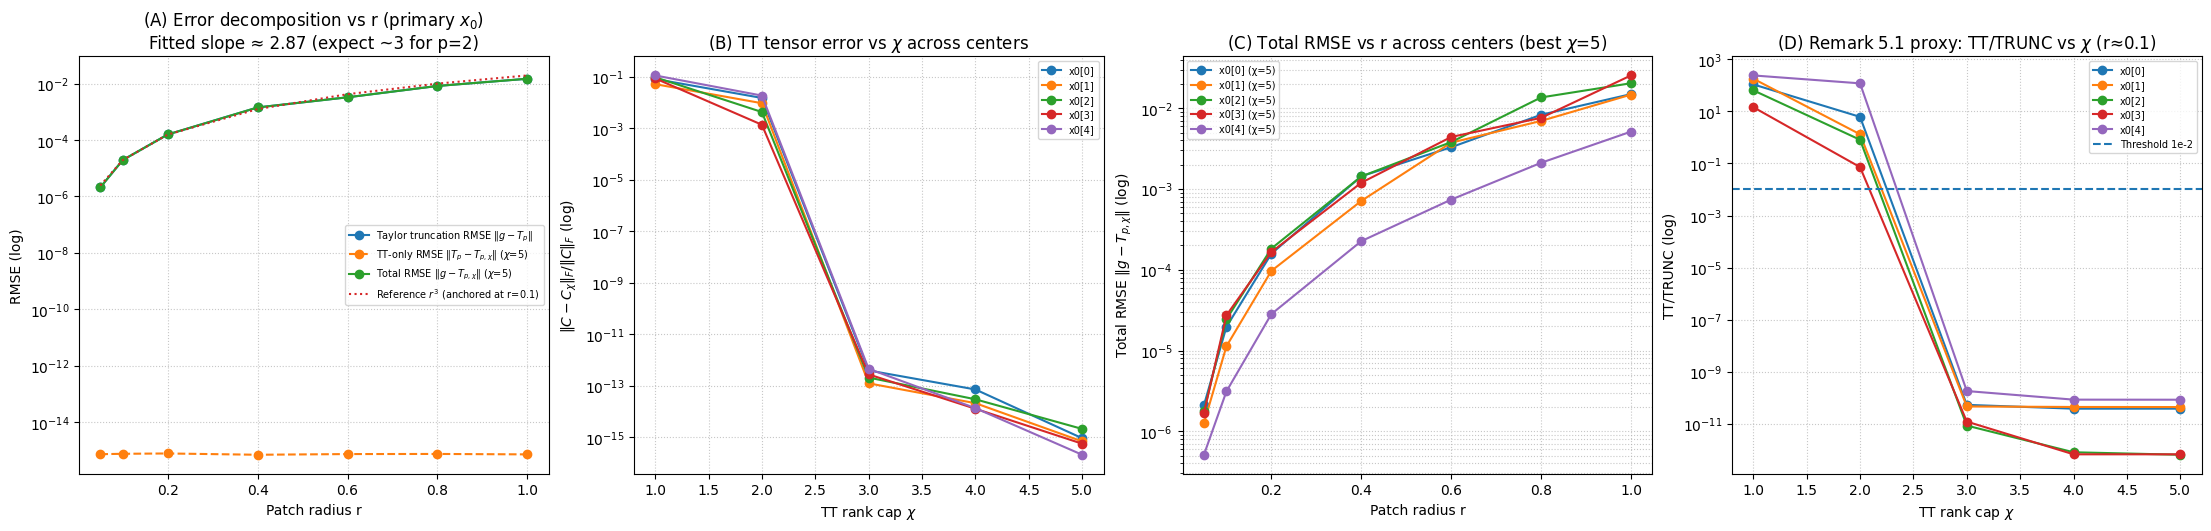

In [5]:
# ============================================================
# 1x4 PAPER PLOTS (Gaussian synthetic)
# - Panel A: truncation, TT-only(best chi), total(best chi), r^3 reference
# - Panel B: TT tensor error vs chi across x0 centers
# - Panel C: Total RMSE vs radius across x0 centers (best chi)
# - Panel D: Remark 5.1 proxy TT/TRUNC vs chi (computed at r_target≈0.1)


import numpy as np
import matplotlib.pyplot as plt

def _safe_get_primary_and_all():
    if "all_summaries" in globals() and isinstance(all_summaries, (list, tuple)) and len(all_summaries) > 0:
        allS = list(all_summaries)
        prim = globals().get("primary_summary", allS[0])
        return prim, allS
    if "primary_summary" in globals() and isinstance(primary_summary, dict):
        return primary_summary, [primary_summary]
    raise RuntimeError("Need `all_summaries` (preferred) or at least `primary_summary` in namespace.")

def _infer_radii_and_chi_list(summary):
    radii = sorted({float(sr["radius"]) for sr in summary["sweep_results"]})
    chi_list = sorted({int(r["chi"]) for r in summary["all_results"]})
    return radii, chi_list

def _nearest_radius(summary, r_target=0.10):
    radii, _ = _infer_radii_and_chi_list(summary)
    return min(radii, key=lambda r: abs(r - r_target))

def _lookup_allres(summary, radius, chi):
    for r in summary["all_results"]:
        if float(r["radius"]) == float(radius) and int(r["chi"]) == int(chi):
            return r
    raise KeyError(f"Missing entry for radius={radius}, chi={chi}")

def _get_trunc_rmse(summary, radius):
    for r in summary["all_results"]:
        if float(r["radius"]) == float(radius):
            return float(r["taylor_rmse"])
    raise KeyError(f"Missing truncation entry for radius={radius}")

def _fit_power_law(radii, y, rmin=None, rmax=None):
    r = np.array(radii, dtype=float)
    yy = np.array(y, dtype=float)
    mask = np.isfinite(r) & np.isfinite(yy) & (r > 0) & (yy > 0)
    if rmin is not None:
        mask &= (r >= rmin)
    if rmax is not None:
        mask &= (r <= rmax)
    r = r[mask]
    yy = yy[mask]
    if len(r) < 2:
        return np.nan, np.nan
    A = np.vstack([np.ones_like(r), np.log(r)]).T
    coef, *_ = np.linalg.lstsq(A, np.log(yy), rcond=None)
    a, b = coef[0], coef[1]
    return float(np.exp(a)), float(b)

# ----------- gather data -----------
primary_summary, allS = _safe_get_primary_and_all()
radii, chi_list = _infer_radii_and_chi_list(primary_summary)
best_chi = max(chi_list)
r_target = _nearest_radius(primary_summary, r_target=0.10)

# Panel A (primary x0 only)
trunc = np.array([_get_trunc_rmse(primary_summary, r) for r in radii], dtype=float)
tt_only_best = np.array([float(_lookup_allres(primary_summary, r, best_chi)["tt_only_rmse"]) for r in radii], dtype=float)
total_best = np.array([float(_lookup_allres(primary_summary, r, best_chi)["total_rmse"]) for r in radii], dtype=float)

# r^3 reference anchored at r_target
anchor_idx = int(np.argmin([abs(r - r_target) for r in radii]))
anchor_r = float(radii[anchor_idx])
anchor_y = float(trunc[anchor_idx])
ref_r3 = anchor_y * (np.array(radii, dtype=float) / anchor_r) ** 3

# fitted slope for truncation
rmin_fit = radii[1] if len(radii) > 1 else radii[0]
c_fit, slope_fit = _fit_power_law(radii, trunc, rmin=rmin_fit, rmax=max(radii))

# Panel B: TT tensor error vs chi across centers (radius-independent; use r_target for lookup)
tt_tensor_by_center = []
for s in allS:
    tt_tensor_by_center.append([float(_lookup_allres(s, r_target, chi)["tt_tensor_rel"]) for chi in chi_list])

# Panel C: total RMSE vs radius across centers (best chi)
total_by_center = []
for s in allS:
    total_by_center.append([float(_lookup_allres(s, r, best_chi)["total_rmse"]) for r in radii])

# Panel D: Remark 5.1 proxy TT/TRUNC vs chi at r_target
ratio_by_center = []
for s in allS:
    trunc_r = _get_trunc_rmse(s, r_target)
    ratio_by_center.append([
        float(_lookup_allres(s, r_target, chi)["tt_only_rmse"]) / (trunc_r + 1e-30)
        for chi in chi_list
    ])

# ----------- plot 1x4 (horizontal) -----------
fig, axs = plt.subplots(1, 4, figsize=(22, 5.2), constrained_layout=True)

# (A)
ax = axs[0]
ax.plot(radii, trunc, marker="o", label=r"Taylor truncation RMSE $\|g - T_p\|$")
ax.plot(radii, tt_only_best, marker="o", linestyle="--",
        label=fr"TT-only RMSE $\|T_p - T_{{p,\chi}}\|$ ($\chi$={best_chi})")
ax.plot(radii, total_best, marker="o",
        label=fr"Total RMSE $\|g - T_{{p,\chi}}\|$ ($\chi$={best_chi})")
ax.plot(radii, ref_r3, linestyle=":", label=fr"Reference $r^3$ (anchored at r={anchor_r:g})")
ax.set_yscale("log")
ax.set_xlabel("Patch radius r")
ax.set_ylabel("RMSE (log)")
title = "(A) Error decomposition vs r (primary $x_0$)"
if np.isfinite(slope_fit):
    title += f"\nFitted slope ≈ {slope_fit:.2f} (expect ~3 for p=2)"
ax.set_title(title)
ax.grid(True, which="both", linestyle=":", alpha=0.7)
ax.legend(fontsize=7, loc="best")

# (B)
ax = axs[1]
for i, s in enumerate(allS):
    ax.plot(chi_list, tt_tensor_by_center[i], marker="o", label=f"x0[{s['x0_idx']}]")
ax.set_yscale("log")
ax.set_xlabel(r"TT rank cap $\chi$")
ax.set_ylabel(r"$\|C - C_\chi\|_F / \|C\|_F$ (log)")
ax.set_title("(B) TT tensor error vs $\\chi$ across centers")
ax.grid(True, which="both", linestyle=":", alpha=0.7)
ax.legend(fontsize=7, loc="best")

# (C)
ax = axs[2]
for i, s in enumerate(allS):
    ax.plot(radii, total_by_center[i], marker="o", label=f"x0[{s['x0_idx']}] (χ={best_chi})")
ax.set_yscale("log")
ax.set_xlabel("Patch radius r")
ax.set_ylabel(r"Total RMSE $\|g - T_{p,\chi}\|$ (log)")
ax.set_title(f"(C) Total RMSE vs r across centers (best $\\chi$={best_chi})")
ax.grid(True, which="both", linestyle=":", alpha=0.7)
ax.legend(fontsize=7, loc="best")

# (D)
ax = axs[3]
for i, s in enumerate(allS):
    ax.plot(chi_list, ratio_by_center[i], marker="o", label=f"x0[{s['x0_idx']}]")
ax.axhline(1e-2, linestyle="--", label="Threshold 1e-2")
ax.set_yscale("log")
ax.set_xlabel(r"TT rank cap $\chi$")
ax.set_ylabel(r"TT/TRUNC (log)")
ax.set_title(f"(D) Remark 5.1 proxy: TT/TRUNC vs $\\chi$ (r≈{r_target:g})")
ax.grid(True, which="both", linestyle=":", alpha=0.7)
ax.legend(fontsize=7, loc="best")

plt.show()